In [1]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import os
from ecemetrics import ERT
os.environ['PYTHONWARNINGS'] = 'ignore::FutureWarning'
from classifiers import *
from calibration_generators import *
from ecemetrics.losses import *

In [ ]:
def overconfident_binary_centered(p):
    logits  = invert_sigmoid(p)
    h = sigmoid( logits * 0.4 )
    return h

def underconfident_binary_centered(p):
    logits  = invert_sigmoid(p)
    return sigmoid( logits * 4 )

def under_and_over_confident_binary_centered(p):
    logits  = invert_sigmoid(p)
    h1 = sigmoid( logits * 0.4 )
    h2 = sigmoid( logits * 4 )
    h1[h1>1/2] = h2[h1>1/2]
    return h1

Results for the perturbation <function underconfident_binary_centered at 0x16b2d0180>
L1-ECE :  0.12741995078059676
Over confidence : -7.969170869827434e-07
Under confidence : 0.1238160798051807
L1-CE : 0.12381528288809371
Results for the perturbation <function underconfident_binary_centered at 0x16b2d0180>
L1-ECE :  0.12737437910655278
Over confidence : -0.0010677587475742805
Under confidence : 0.1257591001897437
L1-CE : 0.1246913414421694
Results for the perturbation <function underconfident_binary_centered at 0x16b2d0180>
L1-ECE :  0.12735525019523564
Over confidence : -0.0006174212851396203
Under confidence : 0.12606303062006655
L1-CE : 0.12544560933492693
Results for the perturbation <function underconfident_binary_centered at 0x16b2d0180>
L1-ECE :  0.1277773900793375
Over confidence : -0.0009633968752133114
Under confidence : 0.12731137148463612
L1-CE : 0.1263479746094228
Results for the perturbation <function underconfident_binary_centered at 0x16b2d0180>
L1-ECE :  0.12724045107

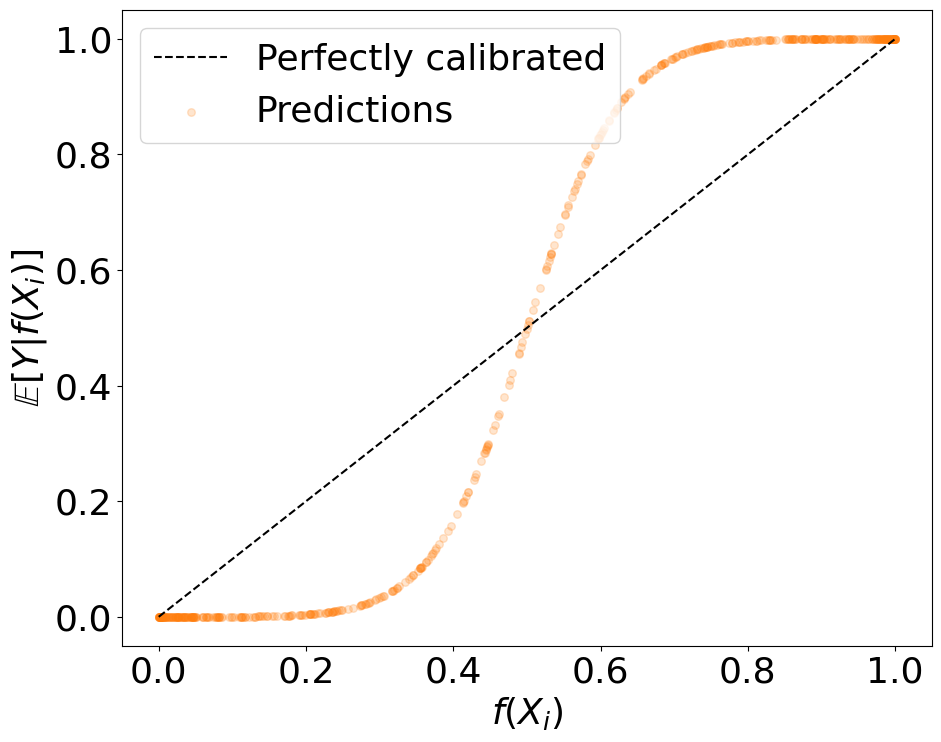

Results for the perturbation <function under_and_over_confident_binary_centered at 0x16b2d0220>
L1-ECE :  0.127580130797377
Over confidence : 0.06746546592397043
Under confidence : 0.06600833818980385
L1-CE : 0.13347380411377424
Results for the perturbation <function under_and_over_confident_binary_centered at 0x16b2d0220>
L1-ECE :  0.12828140157300885
Over confidence : 0.05579520811502479
Under confidence : 0.06189200488869333
L1-CE : 0.11768721300371812
Results for the perturbation <function under_and_over_confident_binary_centered at 0x16b2d0220>
L1-ECE :  0.1277999279282184
Over confidence : 0.06135812710241677
Under confidence : 0.0587085891189799
L1-CE : 0.12006671622139668
Results for the perturbation <function under_and_over_confident_binary_centered at 0x16b2d0220>
L1-ECE :  0.12824644525246576
Over confidence : 0.06538114463137049
Under confidence : 0.06709684043338013
L1-CE : 0.13247798506475061
Results for the perturbation <function under_and_over_confident_binary_centered 

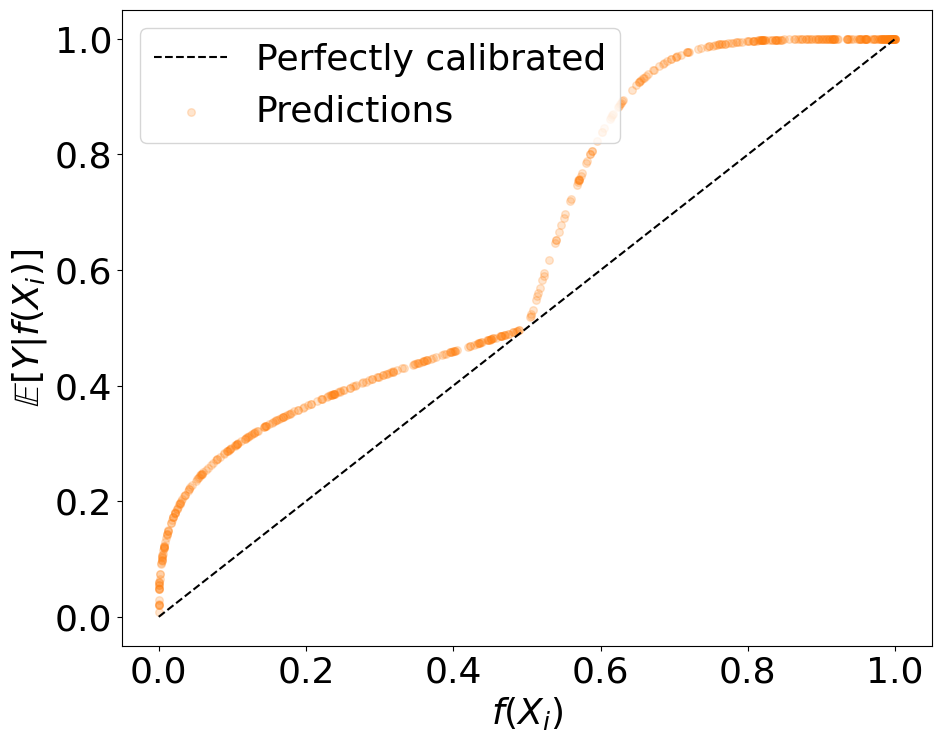

Results for the perturbation <function overconfident_binary_centered at 0x16d32fce0>
L1-ECE :  0.12868156821950674
Over confidence : 0.12810119534167383
Under confidence : 0.00023764186005539135
L1-CE : 0.12833883720172923
Results for the perturbation <function overconfident_binary_centered at 0x16d32fce0>
L1-ECE :  0.1289185219749902
Over confidence : 0.1275682154064834
Under confidence : -0.0013634250593635236
L1-CE : 0.1262047903471199
Results for the perturbation <function overconfident_binary_centered at 0x16d32fce0>
L1-ECE :  0.12848186499091316
Over confidence : 0.12400536551749639
Under confidence : -0.0022338015651987503
L1-CE : 0.12177156395229764
Results for the perturbation <function overconfident_binary_centered at 0x16d32fce0>
L1-ECE :  0.12879789215196602
Over confidence : 0.1344190794591408
Under confidence : 0.0017347132164180102
L1-CE : 0.13615379267555885
Results for the perturbation <function overconfident_binary_centered at 0x16d32fce0>
L1-ECE :  0.1286075784216326

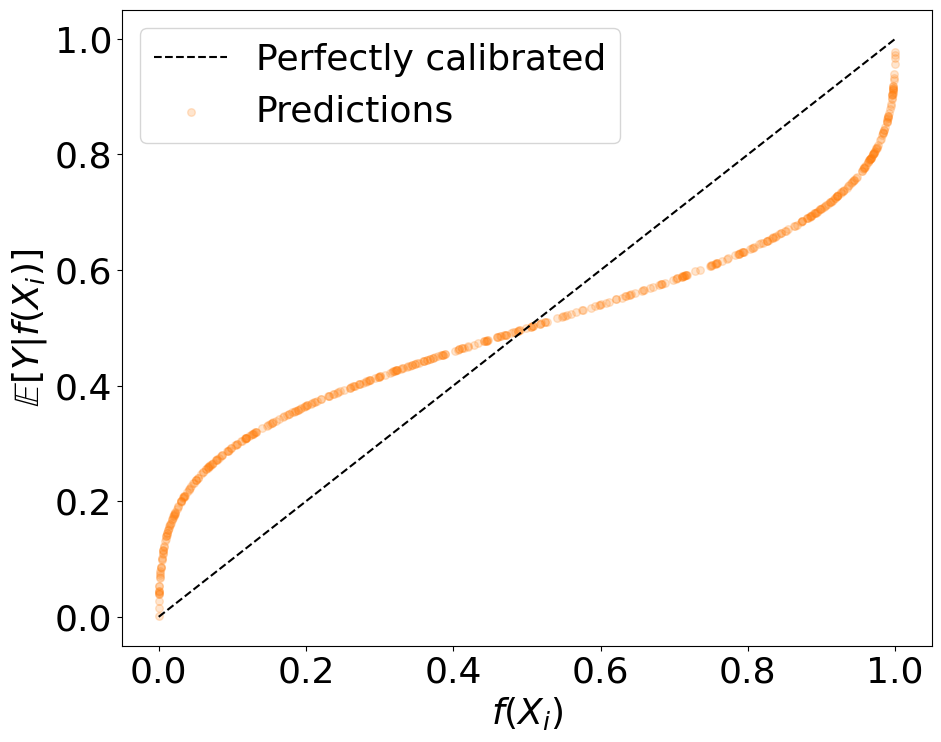

In [23]:
import pandas as pd

n_experiments = 10
n_samples = 5_000

df_results = pd.DataFrame()

tab_function_pert = [overconfident_binary_centered, underconfident_binary_centered, under_and_over_confident_binary_centered]
for function_pert in tab_function_pert:
    
    tab_CE_over = []
    tab_CE_under = []
    tab_CE = []

    for i in range(n_experiments):
        sim = BinaryCalibrationSimulator(h_func=function_pert, style="beta")
        true_L1_ECE = sim.calculate_true_L1_ece()

        preds = sim.generate_preds(n_samples=n_samples)
        logits = multiclass_probs_to_logits(preds)
        labels = sim.generate_labels(preds=preds)

        for model in [
            InitLogitCatboostClassifier,
            # InitLogitXGBClassifier
        ]:

            over_metrics = ERT(model).evaluate(preds.reshape(-1, 1), labels, init_logits=logits, loss=L1_ECE_over)
            under_metrics = ERT(model).evaluate(preds.reshape(-1, 1), labels, init_logits=logits, loss=L1_ECE_under)
            ece_metrics = ERT(model).evaluate(preds.reshape(-1, 1), labels, init_logits=logits, loss=L1_ECE)
            print(f"Results for the perturbation {function_pert}")
            print("L1-ECE : ", sim.calculate_true_L1_ece() )
            print("Over confidence :", over_metrics)
            print("Under confidence :", under_metrics)
            print("L1-CE :", ece_metrics)

            new_row = {
                "function":function_pert.__name__,
                "over_metrics_L1":over_metrics,
                "under_metrics_L1":under_metrics,
                "ece_metrics_L1":ece_metrics,
                "true_L1_ECE":true_L1_ECE,
            }

            df_results = pd.concat([df_results, pd.DataFrame([new_row])], ignore_index = True)

    # sim.plot_analysis(preds=preds, h_func=function_pert, h_name="Underconfident (Sigmoid)")
    true_probs = function_pert(preds)

    plt.rcParams.update({'font.size': 26, 'axes.labelsize': 26, 'xtick.labelsize': 26, 'ytick.labelsize': 26, 'legend.fontsize': 26})

    n_preds_to_plot = 500
    p_grid = np.linspace(0, 1, 100)
    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.get_cmap('tab10')

    ax.plot(p_grid, p_grid, 'k--', label="Perfectly calibrated")
    ax.scatter(preds[:n_preds_to_plot], 
            true_probs[:n_preds_to_plot], 
            alpha=0.2, 
            color=cmap(1), 
            s=30,  # Increased size slightly for visibility with large fonts
            label="Predictions")

    ax.set_xlabel(r"$f(X_i)$")
    ax.set_ylabel(r"$\mathbb{E}[Y|f(X_i)]$")

    ax.legend(loc="upper left")
    plt.tight_layout()
    # 
    plt.savefig(f"../{function_pert.__name__}.pdf", dpi=300)
    plt.show()



In [ ]:
tab_function_pert = [overconfident_binary_centered, underconfident_binary_centered, under_and_over_confident_binary_centered]
df_results.to_csv("../results/over_under.csv")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import sem

df_results = pd.read_csv("../results/over_under.csv")

tab_function_pert_name = [f.__name__ for f in tab_function_pert]
tab_metrics = {
    "over_metrics_L1": r"$\widehat{\mathrm{CE}}_{\|Over(\cdot)\|}$",
    "under_metrics_L1": r"$\widehat{\mathrm{CE}}_{\|Under(\cdot)\|}$",
    "ece_metrics_L1": r"$\widehat{\mathrm{CE}}_{\|\cdot\|}$",
    "true_L1_ECE": r"$\mathrm{CE}_{\|\cdot\|}$",
}

setups_names = {
    "overconfident_binary_centered" : "Over-confident",
    "underconfident_binary_centered" : "Under-confident",
    "under_and_over_confident_binary_centered" : "Both",
}


latex_lines = []
latex_lines.append(r"\begin{table}[h!]")
latex_lines.append(r"\centering")
latex_lines.append(r"\begin{tabular}{lccc}") 
row_str = f""
for setup, names in setups_names.items():
    row_str += f"& {names}"
row_str += "\\\\"
latex_lines.append(row_str)
latex_lines.append(r"\midrule")

for metric, name in tab_metrics.items():
    row_str = f"{name}"
    for pert in tab_function_pert_name:
        df = df_results[df_results["function"] == pert]
        mean_value = max(df[metric].mean(), 0.0)
        sem_value = df[metric].sem()    
        row_str += f"& ${mean_value:.3f}_{{{sem_value:.2f}}}$ "
    row_str += "\\\\"
    latex_lines.append(row_str)

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\caption{\textbf{CE recovered for the different over- and under-confident setups in \Cref{fig:app:prediction:over:under}} Values are averaged over 10 independant runs, and the rectification is estimated with a Catboost with an initialization. Index number is the standard error across all experiments.}")
latex_lines.append(r"\label{table:over:under}")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)
print(latex_table)

\begin{table}[h!]
\centering
\begin{tabular}{lccc}
& Over-confident& Under-confident& Both\\
\midrule
$\widehat{\mathrm{CE}}_{\|Over(\cdot)\|}$& $0.128_{0.00}$ & $0.000_{0.00}$ & $0.062_{0.00}$ \\
$\widehat{\mathrm{CE}}_{\|Under(\cdot)\|}$& $0.000_{0.00}$ & $0.126_{0.00}$ & $0.063_{0.00}$ \\
$\widehat{\mathrm{CE}}_{\|\cdot\|}$& $0.127_{0.00}$ & $0.125_{0.00}$ & $0.125_{0.00}$ \\
$\mathrm{CE}_{\|\cdot\|}$& $0.129_{0.00}$ & $0.128_{0.00}$ & $0.128_{0.00}$ \\
\bottomrule
\end{tabular}
\caption{\textbf{CE recovered for the different over- and under-confident setups in \Cref{fig:app:prediction:over:under}} Values are averaged over 10 independant runs, and the rectification is estimated with a Catboost with an initialization. Index number is the standard error across all experiments.}
\label{table:over:under}
\end{table}
